In [6]:
# =========================
# 10.A1 · Params: w/o Behavior（Fused3 vs Fused2）
# =========================
from pathlib import Path

TMP_DIR = Path("./tmp").resolve()

# 输入图（均为“行随机 + topK=50”的分片图）
TAG_SYM_PREFIX   = "S_tag_symrow"
TEXT_SYM_PREFIX  = "S_text_symrow"
BEH_SYM_PREFIX   = "S_beh_symrow"
FUSED3_PREFIX    = "S_fused3_symrow"   # 我们的主方法

# 评测@K（只在检索结果上取前K）
K_EVAL = 20

# Tag 任务：默认抽样以控制耗时；None 表示全量
TAG_EVAL_SAMPLE_N = 100_000  # or None

# 输出文件
OUT_TABLE_CSV  = TMP_DIR / "exp_A1_table.csv"
OUT_FIG_PNG    = TMP_DIR / "exp_A1_ndcg20.png"


In [8]:
# =========================
# 10.A1 · Execute
# =========================
import json, math, heapq, numpy as np, pandas as pd
from pathlib import Path
from scipy import sparse
import matplotlib.pyplot as plt

def _require(p: Path, desc: str):
    assert p.exists(), f"[FATAL] 缺少 {desc}: {p.as_posix()}"

def _load_manifest(prefix: str):
    mans = sorted(TMP_DIR.glob(f"{prefix}_k*_manifest.json"))
    assert mans, f"[FATAL] 未找到 {prefix} 的 manifest"
    mp = mans[0]
    man = json.loads(Path(mp).read_text())
    parts = [TMP_DIR / p for p in man["parts"]]
    nodes = int(man.get("nodes", 0))
    print(f"[MAN] {mp.name}  parts={len(parts)}  nnz={int(man.get('nnz', -1)):,}")
    return parts, nodes

def _build_csr(parts, n_nodes: int) -> sparse.csr_matrix:
    rows, cols, vals, tot = [], [], [], 0
    for i, fp in enumerate(parts, 1):
        df = pd.read_parquet(fp, engine="fastparquet")
        rows.append(df["row"].to_numpy(np.int64, copy=False))
        cols.append(df["col"].to_numpy(np.int64, copy=False))
        vals.append(df["val"].to_numpy(np.float32, copy=False))
        tot += len(df)
        if (i % 4)==0 or i==len(parts):
            print(f"[LOAD] {i}/{len(parts)} parts, edges so far={tot:,}")
        del df
    if rows:
        r = np.concatenate(rows); c = np.concatenate(cols); v = np.concatenate(vals)
    else:
        r = np.empty(0, dtype=np.int64); c = np.empty(0, dtype=np.int64); v = np.empty(0, dtype=np.float32)
    A = sparse.coo_matrix((v,(r,c)), shape=(n_nodes, n_nodes), dtype=np.float32).tocsr()
    A.sum_duplicates(); A.eliminate_zeros()
    print(f"[CSR] nnz={A.nnz:,}")
    return A

def row_rho(P: sparse.csr_matrix) -> np.ndarray:
    d2 = (P.data.astype(np.float64) ** 2)
    cs = np.empty(d2.size + 1, dtype=np.float64); cs[0] = 0.0
    np.cumsum(d2, out=cs[1:])
    ind = P.indptr
    return cs[ind[1:]] - cs[ind[:-1]]

def scale_rows(P: sparse.csr_matrix, alpha: np.ndarray) -> sparse.csr_matrix:
    P = P.tocsr(copy=True)
    deg = np.diff(P.indptr)
    rep = np.repeat(alpha, deg)
    P.data = P.data * rep.astype(np.float32)
    return P

def csr_row_topk(P: sparse.csr_matrix, k: int) -> sparse.csr_matrix:
    indptr, indices, data = P.indptr, P.indices, P.data
    N = P.shape[0]
    deg = np.diff(indptr)
    k_keep = np.minimum(k, deg)
    nnz_keep = int(k_keep.sum())
    new_indptr = np.zeros(N+1, dtype=np.int64)
    new_indptr[1:] = np.cumsum(k_keep)
    new_indices = np.empty(nnz_keep, dtype=np.int64)
    new_data    = np.empty(nnz_keep, dtype=np.float32)
    pos = 0
    for i in range(N):
        s, e = indptr[i], indptr[i+1]; kk = k_keep[i]
        if kk == 0: continue
        idx = indices[s:e]; val = data[s:e]
        if e - s <= k:
            new_indices[pos:pos+kk] = idx
            new_data[pos:pos+kk]    = val
        else:
            part = np.argpartition(val, -kk)[-kk:]
            ords = np.argsort(-val[part]); sel = part[ords]
            new_indices[pos:pos+kk] = idx[sel]
            new_data[pos:pos+kk]    = val[sel]
        pos += kk
    out = sparse.csr_matrix((new_data, new_indices, new_indptr), shape=P.shape, dtype=np.float32)
    out.eliminate_zeros()
    return out

def row_normalize(P: sparse.csr_matrix, eps: float=1e-12) -> sparse.csr_matrix:
    rs = np.asarray(P.sum(axis=1)).ravel().astype(np.float64)
    rs[rs < eps] = 1.0
    inv = (1.0/rs).astype(np.float32)
    return (sparse.diags(inv) @ P).tocsr()

# ---------- 1) 构建 Fused2-RA（Tag+Text，自适应；不落盘） ----------
tag_parts, N = _load_manifest(TAG_SYM_PREFIX)
text_parts, N2 = _load_manifest(TEXT_SYM_PREFIX)
assert N==N2, "[FATAL] 节点数不一致"

P_tag  = _build_csr(tag_parts,  N)
P_text = _build_csr(text_parts, N)

rho_tag  = row_rho(P_tag)
rho_text = row_rho(P_text)
den = rho_tag + rho_text + 1e-12
alpha_tag  = rho_tag  / den
alpha_text = rho_text / den

print("[A1] 行自适应权重统计（Fused2-RA）:")
print(f"  - alpha_tag : min={alpha_tag.min():.4f}, med={np.median(alpha_tag):.4f}, max={alpha_tag.max():.4f}")
print(f"  - alpha_text: min={alpha_text.min():.4f}, med={np.median(alpha_text):.4f}, max={alpha_text.max():.4f}")

P_sum = scale_rows(P_tag, alpha_tag) + scale_rows(P_text, alpha_text)
del P_tag, P_text, rho_tag, rho_text, alpha_tag, alpha_text
P_sum.sum_duplicates(); P_sum.eliminate_zeros()
print(f"[A1] Fused2-RA（未裁剪） nnz={P_sum.nnz:,}")

P2 = csr_row_topk(P_sum, 50)
P2 = row_normalize(P2)
del P_sum
print(f"[A1] Fused2-RA（行随机，top-50） nnz={P2.nnz:,}")

# ---------- 2) 读取 Fused3（Ours） ----------
f3_parts, N3 = _load_manifest(FUSED3_PREFIX)
assert N3==N, "[FATAL] 节点数不一致（Fused3 vs Fused2）"
P3 = _build_csr(f3_parts, N)  # 行随机 top-50

# ---------- 3) 准备相关性信息（Tag/Org/Creator） ----------
# Org/Creator
beh_base = pd.read_parquet(TMP_DIR / "beh_base.parquet", engine="fastparquet")
beh_base = beh_base.sort_values("doc_idx")
assert (beh_base["doc_idx"].to_numpy() == np.arange(N)).all()
org_arr = beh_base["OwnerOrganizationId"].to_numpy()
cre_arr = beh_base["CreatorUserId"].to_numpy()

# ---------- 3b) Tag 相关性（不依赖 doc_clean.tag_list；改用 DT_ppmi） ----------
# 用 DT_ppmi（D–T 稀疏）判断“是否共享至少 1 个保留标签”
DT_path = TMP_DIR / "DT_ppmi.parquet"
assert DT_path.exists(), f"[FATAL] 缺少 DT_ppmi: {DT_path}"

# 读入 DT_ppmi 分片（如果是单文件就直接读）
DT_df = pd.read_parquet(DT_path, engine="fastparquet")
# 需要确保 col 索引从 0..T-1 连续；若 vocab 存在，用它校验长度
tagv_path = TMP_DIR / "tag_vocab.parquet"
T = int(DT_df["col"].max()) + 1
if tagv_path.exists():
    tagv = pd.read_parquet(tagv_path, engine="fastparquet")
    # 某些流程里 vocab 只有 tag 文本，不含显式列号也没关系；这里仅作一致性提示
    print(f"[TAG] kept tags ≈ {len(tagv)}; DT_ppmi cols (inferred) = {T}")

# 构 CSR（行=doc_idx, 列=tag_idx），并保证行内列索引有序，便于两指针相交
from scipy import sparse
DT = sparse.coo_matrix(
    (DT_df["val"].to_numpy(np.float32, copy=False),
     (DT_df["row"].to_numpy(np.int64, copy=False),
      DT_df["col"].to_numpy(np.int64, copy=False))),
    shape=(N, T), dtype=np.float32
).tocsr()
DT.sort_indices()
del DT_df

DT_indptr = DT.indptr
DT_indices = DT.indices
del DT  # 节省内存，仅保留 indptr/indices 即可

def _share_tag_nonempty(i: int, j: int) -> bool:
    """判断第 i 与 j 行在 DT_ppmi 中是否共享至少1个标签（两指针相交，行内已排序）"""
    a = DT_indices[DT_indptr[i]:DT_indptr[i+1]]
    b = DT_indices[DT_indptr[j]:DT_indptr[j+1]]
    # 快速排除
    if a.size == 0 or b.size == 0:
        return False
    # 两指针
    p = q = 0
    while p < a.size and q < b.size:
        if a[p] == b[q]:
            return True
        if a[p] < b[q]:
            p += 1
        else:
            q += 1
    return False

# ---------- 4) 评测函数：二值标签 ----------
def make_topk_from_csr(P: sparse.csr_matrix, K:int) -> list:
    """返回长度 N 的列表，每个元素是 list[(col,val)]，按 val 降序截取 K。"""
    N = P.shape[0]
    indptr, indices, data = P.indptr, P.indices, P.data
    out = [None]*N
    for i in range(N):
        s, e = indptr[i], indptr[i+1]
        idx = indices[s:e]; val = data[s:e]
        if e - s <= K:
            order = np.argsort(-val)
            cols = idx[order]; vals = val[order]
        else:
            part = np.argpartition(val, -K)[-K:]
            ords = np.argsort(-val[part])
            sel  = part[ords]
            cols = idx[sel]; vals = val[sel]
        out[i] = list(zip(cols.tolist(), vals.tolist()))
    return out

print("[A1] 提取 top-20 列表（Fused2 / Fused3） ...")
top2 = make_topk_from_csr(P2, K_EVAL)  # Fused2-RA
top3 = make_topk_from_csr(P3, K_EVAL)  # Fused3-RA

def dcg_at_k(rel, k):
    rel = np.asarray(rel, dtype=np.float32)[:k]
    if rel.size == 0: return 0.0
    denom = np.log2(np.arange(2, rel.size+2, dtype=np.float32))
    return float((rel / denom).sum())

def idcg_at_k(R, k):
    # 二值相关：理想 DCG = 1/log2(2) + ... up to min(R,k)
    m = int(min(R, k))
    if m <= 0: return 0.0
    denom = np.log2(np.arange(2, m+2, dtype=np.float32))
    return float((np.ones(m, dtype=np.float32) / denom).sum())

def avg_precision_at_k(rel, k):
    # rel 二值，取前 k
    r = np.asarray(rel, dtype=np.int32)[:k]
    if r.sum() == 0: return 0.0
    cumsum = np.cumsum(r)
    precs = cumsum / (np.arange(1, r.size+1))
    return float((precs * r).sum() / r.sum())

def mrr_at_k(rel, k):
    r = np.asarray(rel, dtype=np.int32)[:k]
    idx = np.where(r == 1)[0]
    if idx.size == 0: return 0.0
    return float(1.0 / (idx[0] + 1))

def eval_binary(top_list, is_rel_fn, total_rel_count_fn=None):
    # 返回 micro 平均（对每个 query 取指标，再平均）
    n = len(top_list)
    ndcgs, maps, mrrs, precs = [], [], [], []
    cover = 0
    for i in range(n):
        neigh = top_list[i]
        rel = [1 if is_rel_fn(i, j) else 0 for j, _ in neigh]
        R = None
        if total_rel_count_fn is not None:
            R = total_rel_count_fn(i)
        # coverage
        cover += (sum(rel) > 0)
        # metrics
        dcg = dcg_at_k(rel, K_EVAL)
        idcg = idcg_at_k(R if R is not None else sum(rel), K_EVAL)
        ndcg = (dcg / idcg) if idcg > 0 else 0.0
        ndcgs.append(ndcg)
        maps.append(avg_precision_at_k(rel, K_EVAL))
        mrrs.append(mrr_at_k(rel, K_EVAL))
        precs.append(np.mean(rel) if rel else 0.0)
    return {
        "n": n,
        "nDCG@20": float(np.mean(ndcgs)),
        "MAP@20": float(np.mean(maps)),
        "MRR@20": float(np.mean(mrrs)),
        "P@20": float(np.mean(precs)),
        "Coverage": cover / n
    }

# ---------- 5) 三个任务的相关性定义 ----------
# Tag（二值）：共享 ≥1 kept_tag（通过 DT_ppmi 的行相交判断）
def is_rel_tag(i, j):
    return _share_tag_nonempty(i, j)

# Org：同 OwnerOrganizationId，且非缺失
def is_rel_org(i, j):
    oi, oj = org_arr[i], org_arr[j]
    return (not (np.isnan(oi) or np.isnan(oj))) and (oi == oj)

# Creator：同 CreatorUserId（数值整型），且非缺失
def is_rel_cre(i, j):
    return (not np.isnan(cre_arr[i])) and (cre_arr[i] == cre_arr[j])

# Org/Creator 的 R（总相关数）精确计数（保留你原来的 Counter 逻辑）
from collections import Counter
org_counts = Counter(org_arr[~np.isnan(org_arr)])
cre_counts = Counter(cre_arr[~np.isnan(cre_arr)])

def total_rel_org(i):
    oi = org_arr[i]
    if np.isnan(oi): return 0
    return int(org_counts[oi] - 1)  # 排除自身

def total_rel_cre(i):
    ci = cre_arr[i]
    if np.isnan(ci): return 0
    return int(cre_counts[ci] - 1)

# Tag 的 R：仍用“候选并集近似”避免构倒排全表（保持原逻辑）
def total_rel_tag_approx(i, top_list):
    neigh = set([j for j,_ in top2[i]] + [j for j,_ in top3[i]])
    cnt = 0
    for j in neigh:
        if _share_tag_nonempty(i, j):
            cnt += 1
    return cnt

# ---------- 6) 评测 ----------
print("[A1] Eval: Org（全量）")
res_org_f2 = eval_binary(top2, is_rel_org, total_rel_org)
res_org_f3 = eval_binary(top3, is_rel_org, total_rel_org)

print("[A1] Eval: Creator（全量）")
res_cre_f2 = eval_binary(top2, is_rel_cre, total_rel_cre)
res_cre_f3 = eval_binary(top3, is_rel_cre, total_rel_cre)

# Tag：默认抽样（可将 TAG_EVAL_SAMPLE_N=None 改为全量）
idx_all = np.arange(N)
if TAG_EVAL_SAMPLE_N is not None:
    rng = np.random.default_rng(2025)
    idx_eval = rng.choice(idx_all, size=min(TAG_EVAL_SAMPLE_N, N), replace=False)
else:
    idx_eval = idx_all

def eval_tag_subset(top_list):
    ndcgs, maps, mrrs, precs = [], [], [], []
    cover = 0
    for i in idx_eval:
        rel = [1 if is_rel_tag(i, j) else 0 for j, _ in top_list[i]]
        R = total_rel_tag_approx(i, top_list)
        cover += (sum(rel) > 0)
        dcg = dcg_at_k(rel, K_EVAL)
        idcg = idcg_at_k(R, K_EVAL) if R > 0 else 0.0
        ndcgs.append((dcg / idcg) if idcg > 0 else 0.0)
        maps.append(avg_precision_at_k(rel, K_EVAL))
        mrrs.append(mrr_at_k(rel, K_EVAL))
        precs.append(np.mean(rel))
    return {
        "n": int(len(idx_eval)),
        "nDCG@20": float(np.mean(ndcgs)),
        "MAP@20": float(np.mean(maps)),
        "MRR@20": float(np.mean(mrrs)),
        "P@20": float(np.mean(precs)),
        "Coverage": cover / len(idx_eval)
    }

print(f"[A1] Eval: Tag（二值），样本={len(idx_eval):,}")
res_tag_f2 = eval_tag_subset(top2)
res_tag_f3 = eval_tag_subset(top3)

# ---------- 7) 汇总为表格 ----------
rows = []
def _add_row(method_name, task, res):
    rows.append({
        "Method": method_name,
        "Task": task,
        "n": res["n"],
        "nDCG@20": res["nDCG@20"],
        "MAP@20": res["MAP@20"],
        "MRR@20": res["MRR@20"],
        "P@20": res["P@20"],
        "Coverage": res["Coverage"],
    })

_add_row("Fused2-RA (Tag+Text)", "Tag",     res_tag_f2)
_add_row("Fused3-RA (Ours)",      "Tag",     res_tag_f3)
_add_row("Fused2-RA (Tag+Text)", "Org",     res_org_f2)
_add_row("Fused3-RA (Ours)",      "Org",     res_org_f3)
_add_row("Fused2-RA (Tag+Text)", "Creator", res_cre_f2)
_add_row("Fused3-RA (Ours)",      "Creator", res_cre_f3)

df_out = pd.DataFrame(rows)
df_out.to_csv(OUT_TABLE_CSV, index=False)
print(f"[SAVE] table -> {OUT_TABLE_CSV}")

# ---------- 8) 可视化：A1 一张图（nDCG@20，三任务 × 两方法的分组条形图） ----------
pivot = df_out.pivot(index="Task", columns="Method", values="nDCG@20")
tasks = ["Tag", "Org", "Creator"]
pivot = pivot.loc[tasks]

ax = pivot.plot(kind="bar")
ax.set_title("A1: w/o Behavior — nDCG@20 (higher is better)")
ax.set_xlabel("Task")
ax.set_ylabel("nDCG@20")
ax.legend(title="Method")
plt.tight_layout()
plt.savefig(OUT_FIG_PNG, dpi=160)
print(f"[SAVE] figure -> {OUT_FIG_PNG}")
plt.close()

print("\n[A1] DONE.")


[MAN] S_tag_symrow_k50_manifest.json  parts=15  nnz=28,159,756
[MAN] S_text_symrow_k50_manifest.json  parts=15  nnz=28,161,106
[LOAD] 4/15 parts, edges so far=8,000,000
[LOAD] 8/15 parts, edges so far=16,000,000
[LOAD] 12/15 parts, edges so far=24,000,000
[LOAD] 15/15 parts, edges so far=28,159,756
[CSR] nnz=28,159,756
[LOAD] 4/15 parts, edges so far=8,000,000
[LOAD] 8/15 parts, edges so far=16,000,000
[LOAD] 12/15 parts, edges so far=24,000,000
[LOAD] 15/15 parts, edges so far=28,161,106
[CSR] nnz=28,161,106
[A1] 行自适应权重统计（Fused2-RA）:
  - alpha_tag : min=0.3524, med=0.5000, max=0.6552
  - alpha_text: min=0.3448, med=0.5000, max=0.6476
[A1] Fused2-RA（未裁剪） nnz=56,317,938
[A1] Fused2-RA（行随机，top-50） nnz=26,086,750
[MAN] S_fused3_symrow_k50_manifest.json  parts=14  nnz=26,086,750
[LOAD] 4/14 parts, edges so far=8,000,000
[LOAD] 8/14 parts, edges so far=16,000,000
[LOAD] 12/14 parts, edges so far=24,000,000
[LOAD] 14/14 parts, edges so far=26,086,750
[CSR] nnz=26,086,750
[TAG] kept tags ≈ 39

/tmp/ipykernel_354915/2970223307.py:50: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/2970223307.py:50: UserWarning: Glyph 26356 (\N{CJK UNIFIED IDEOGRAPH-66F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/2970223307.py:50: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/2970223307.py:50: UserWarning: Glyph 22909 (\N{CJK UNIFIED IDEOGRAPH-597D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/2970223307.py:50: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/envs/recsys-torch/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda

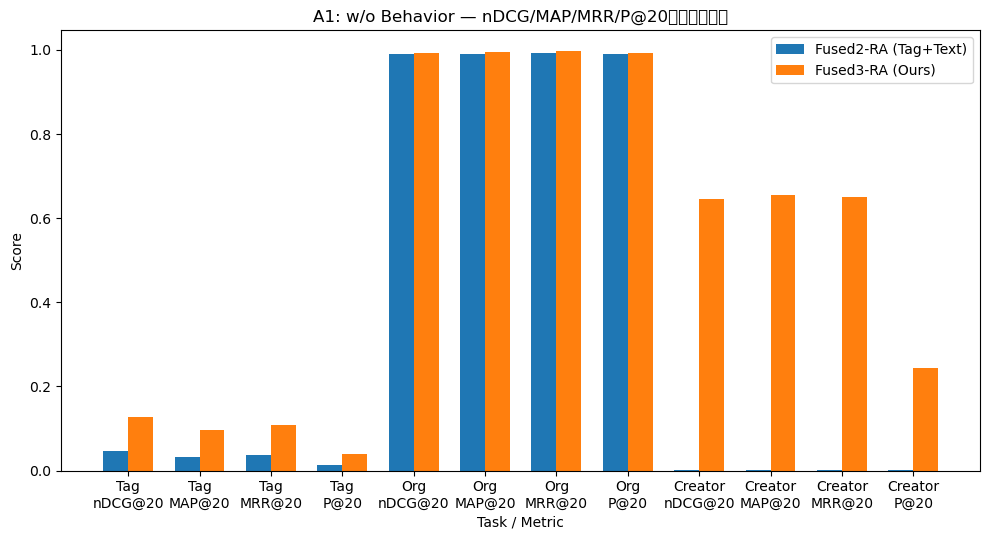

In [9]:
# =========================
# A1 · Plot (one figure, no saving)
# nDCG@20 / MAP@20 / MRR@20 / P@20 并列柱状图（两方法 × 三任务）
# =========================
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = Path("./tmp/exp_A1_table.csv")
assert CSV_PATH.exists(), f"未找到结果表: {CSV_PATH}"

df = pd.read_csv(CSV_PATH)

# 只取我们要的任务和方法（顺序固定，便于对齐）
tasks   = ["Tag", "Org", "Creator"]
metrics = ["nDCG@20", "MAP@20", "MRR@20", "P@20"]
methods = ["Fused2-RA (Tag+Text)", "Fused3-RA (Ours)"]

# 构造绘图数据：按任务分组，每个任务里按 4 个指标，每个指标两根柱（两方法）
# x 轴用 “Task\nMetric” 作为类别标签，形成一个 axes 上的分组柱状图（无子图）
values = {m: [] for m in methods}
x_labels = []

for t in tasks:
    sub = df[df["Task"] == t].set_index("Method")
    for met in metrics:
        for m in methods:
            assert m in sub.index, f"结果表缺少方法：{m}"
            values[m].append(float(sub.loc[m, met]))
        x_labels.append(f"{t}\n{met}")

num_slots = len(x_labels)                  # 3 任务 × 4 指标 = 12 类别
bar_width = 0.35
positions = np.arange(num_slots, dtype=float)

# 两方法在同一类别上的左右偏移（不指定颜色，使用 matplotlib 默认）
offsets = [-bar_width/2, bar_width/2]

plt.figure(figsize=(max(10, num_slots * 0.8), 5.5))
for i, m in enumerate(methods):
    xs = positions + offsets[i]
    plt.bar(xs, values[m], width=bar_width, label=m)

plt.xticks(positions, x_labels, rotation=0, ha="center")
plt.title("A1: w/o Behavior — nDCG/MAP/MRR/P@20（更高更好）")
plt.ylabel("Score")
plt.xlabel("Task / Metric")
plt.legend()
plt.tight_layout()
plt.show()


In [10]:
# =========================
# 10.A2 · Params: Two-view Mean vs RA (Tag+Text)
# =========================
from pathlib import Path

TMP_DIR = Path("./tmp").resolve()

# 输入（均为“行随机 + topK=50”的分片图）
TAG_SYM_PREFIX   = "S_tag_symrow"
TEXT_SYM_PREFIX  = "S_text_symrow"

# 评测@K（只在检索结果上取前K）
K_EVAL = 20

# Tag 任务：默认抽样以控制耗时；None 表示全量
TAG_EVAL_SAMPLE_N = 100_000  # or None

# 输出文件（表格）
OUT_TABLE_CSV  = TMP_DIR / "exp_A2_table.csv"

# 可视化是否保存（本实验仅显示不保存；若要保存，改成 True 并设定路径）
PLOT_SAVE = False
PLOT_PATH = TMP_DIR / "exp_A2_metrics.png"


[MAN] S_tag_symrow_k50_manifest.json  parts=15  nnz=28,159,756
[MAN] S_text_symrow_k50_manifest.json  parts=15  nnz=28,161,106
[LOAD] 4/15 parts, edges so far=8,000,000
[LOAD] 8/15 parts, edges so far=16,000,000
[LOAD] 12/15 parts, edges so far=24,000,000
[LOAD] 15/15 parts, edges so far=28,159,756
[CSR] nnz=28,159,756
[LOAD] 4/15 parts, edges so far=8,000,000
[LOAD] 8/15 parts, edges so far=16,000,000
[LOAD] 12/15 parts, edges so far=24,000,000
[LOAD] 15/15 parts, edges so far=28,161,106
[CSR] nnz=28,161,106
[A2] Mean2（未裁剪） nnz=56,317,938
[A2] Mean2（行随机，top-50） nnz=26,086,750
[A2] 行自适应权重统计（Fused2-RA）:
  - alpha_tag : min=0.3524, med=0.5000, max=0.6552
  - alpha_text: min=0.3448, med=0.5000, max=0.6476
[A2] Fused2-RA（行随机，top-50） nnz=26,086,750
[A2] 提取 top-20 列表（Mean2 / Fused2） ...
[A2] Eval: Org（全量）
[A2] Eval: Creator（全量）
[A2] Eval: Tag（二值），样本=100,000
[SAVE] table -> /home/koyo/workspace/recsys/tmp/exp_A2_table.csv


/tmp/ipykernel_354915/1243383954.py:356: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/1243383954.py:356: UserWarning: Glyph 26356 (\N{CJK UNIFIED IDEOGRAPH-66F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/1243383954.py:356: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/1243383954.py:356: UserWarning: Glyph 22909 (\N{CJK UNIFIED IDEOGRAPH-597D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/1243383954.py:356: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/envs/recsys-torch/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/

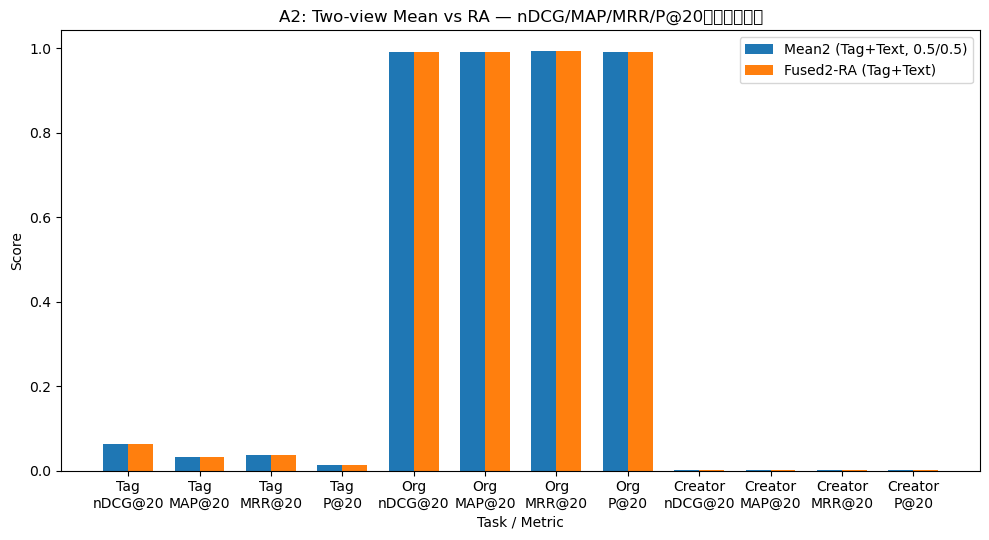


[A2] DONE.


In [11]:
# =========================
# 10.A2 · Execute
# =========================
import json, numpy as np, pandas as pd
from pathlib import Path
from scipy import sparse
import matplotlib.pyplot as plt

def _require(p: Path, desc: str):
    assert p.exists(), f"[FATAL] 缺少 {desc}: {p.as_posix()}"

def _load_manifest(prefix: str):
    mans = sorted(TMP_DIR.glob(f"{prefix}_k*_manifest.json"))
    assert mans, f"[FATAL] 未找到 {prefix} 的 manifest"
    mp = mans[0]
    man = json.loads(Path(mp).read_text())
    parts = [TMP_DIR / p for p in man["parts"]]
    nodes = int(man.get("nodes", 0))
    print(f"[MAN] {mp.name}  parts={len(parts)}  nnz={int(man.get('nnz', -1)):,}")
    return parts, nodes

def _build_csr(parts, n_nodes: int) -> sparse.csr_matrix:
    rows, cols, vals, tot = [], [], [], 0
    for i, fp in enumerate(parts, 1):
        df = pd.read_parquet(fp, engine="fastparquet")
        rows.append(df["row"].to_numpy(np.int64, copy=False))
        cols.append(df["col"].to_numpy(np.int64, copy=False))
        vals.append(df["val"].to_numpy(np.float32, copy=False))
        tot += len(df)
        if (i % 4)==0 or i==len(parts):
            print(f"[LOAD] {i}/{len(parts)} parts, edges so far={tot:,}")
        del df
    if rows:
        r = np.concatenate(rows); c = np.concatenate(cols); v = np.concatenate(vals)
    else:
        r = np.empty(0, dtype=np.int64); c = np.empty(0, dtype=np.int64); v = np.empty(0, dtype=np.float32)
    A = sparse.coo_matrix((v,(r,c)), shape=(n_nodes, n_nodes), dtype=np.float32).tocsr()
    A.sum_duplicates(); A.eliminate_zeros()
    print(f"[CSR] nnz={A.nnz:,}")
    return A

def row_rho(P: sparse.csr_matrix) -> np.ndarray:
    d2 = (P.data.astype(np.float64) ** 2)
    cs = np.empty(d2.size + 1, dtype=np.float64); cs[0] = 0.0
    np.cumsum(d2, out=cs[1:])
    ind = P.indptr
    return cs[ind[1:]] - cs[ind[:-1]]

def scale_rows(P: sparse.csr_matrix, alpha: np.ndarray) -> sparse.csr_matrix:
    P = P.tocsr(copy=True)
    deg = np.diff(P.indptr)
    rep = np.repeat(alpha, deg)
    P.data = P.data * rep.astype(np.float32)
    return P

def csr_row_topk(P: sparse.csr_matrix, k: int) -> sparse.csr_matrix:
    indptr, indices, data = P.indptr, P.indices, P.data
    N = P.shape[0]
    deg = np.diff(indptr)
    k_keep = np.minimum(k, deg)
    nnz_keep = int(k_keep.sum())
    new_indptr = np.zeros(N+1, dtype=np.int64)
    new_indptr[1:] = np.cumsum(k_keep)
    new_indices = np.empty(nnz_keep, dtype=np.int64)
    new_data    = np.empty(nnz_keep, dtype=np.float32)
    pos = 0
    for i in range(N):
        s, e = indptr[i], indptr[i+1]; kk = k_keep[i]
        if kk == 0: continue
        idx = indices[s:e]; val = data[s:e]
        if e - s <= k:
            sel = np.argsort(-val)
            new_indices[pos:pos+kk] = idx[sel]
            new_data[pos:pos+kk]    = val[sel]
        else:
            part = np.argpartition(val, -kk)[-kk:]
            ords = np.argsort(-val[part]); sel = part[ords]
            new_indices[pos:pos+kk] = idx[sel]
            new_data[pos:pos+kk]    = val[sel]
        pos += kk
    out = sparse.csr_matrix((new_data, new_indices, new_indptr), shape=P.shape, dtype=np.float32)
    out.eliminate_zeros()
    return out

def row_normalize(P: sparse.csr_matrix, eps: float=1e-12) -> sparse.csr_matrix:
    rs = np.asarray(P.sum(axis=1)).ravel().astype(np.float64)
    rs[rs < eps] = 1.0
    inv = (1.0/rs).astype(np.float32)
    return (sparse.diags(inv) @ P).tocsr()

def make_topk_from_csr(P: sparse.csr_matrix, K:int) -> list:
    """返回长度 N 的列表，每个元素是 list[(col,val)]，按 val 降序截取 K。"""
    N = P.shape[0]
    indptr, indices, data = P.indptr, P.indices, P.data
    out = [None]*N
    for i in range(N):
        s, e = indptr[i], indptr[i+1]
        idx = indices[s:e]; val = data[s:e]
        if e - s <= K:
            order = np.argsort(-val)
            cols = idx[order]; vals = val[order]
        else:
            part = np.argpartition(val, -K)[-K:]
            ords = np.argsort(-val[part]); sel  = part[ords]
            cols = idx[sel]; vals = val[sel]
        out[i] = list(zip(cols.tolist(), vals.tolist()))
    return out

def dcg_at_k(rel, k):
    rel = np.asarray(rel, dtype=np.float32)[:k]
    if rel.size == 0: return 0.0
    denom = np.log2(np.arange(2, rel.size+2, dtype=np.float32))
    return float((rel / denom).sum())

def idcg_at_k(R, k):
    m = int(min(R, k))
    if m <= 0: return 0.0
    denom = np.log2(np.arange(2, m+2, dtype=np.float32))
    return float((np.ones(m, dtype=np.float32) / denom).sum())

def avg_precision_at_k(rel, k):
    r = np.asarray(rel, dtype=np.int32)[:k]
    if r.sum() == 0: return 0.0
    cumsum = np.cumsum(r)
    precs = cumsum / (np.arange(1, r.size+1))
    return float((precs * r).sum() / r.sum())

def mrr_at_k(rel, k):
    r = np.asarray(rel, dtype=np.int32)[:k]
    idx = np.where(r == 1)[0]
    if idx.size == 0: return 0.0
    return float(1.0 / (idx[0] + 1))

def eval_binary(top_list, is_rel_fn, total_rel_count_fn=None):
    n = len(top_list)
    ndcgs, maps, mrrs, precs = [], [], [], []
    cover = 0
    for i in range(n):
        neigh = top_list[i]
        rel = [1 if is_rel_fn(i, j) else 0 for j, _ in neigh]
        R = None
        if total_rel_count_fn is not None:
            R = total_rel_count_fn(i)
        cover += (sum(rel) > 0)
        dcg = dcg_at_k(rel, K_EVAL)
        idcg = idcg_at_k(R if R is not None else sum(rel), K_EVAL)
        ndcg = (dcg / idcg) if idcg > 0 else 0.0
        ndcgs.append(ndcg)
        maps.append(avg_precision_at_k(rel, K_EVAL))
        mrrs.append(mrr_at_k(rel, K_EVAL))
        precs.append(np.mean(rel) if rel else 0.0)
    return {
        "n": n,
        "nDCG@20": float(np.mean(ndcgs)),
        "MAP@20": float(np.mean(maps)),
        "MRR@20": float(np.mean(mrrs)),
        "P@20": float(np.mean(precs)),
        "Coverage": cover / n
    }

# ---------- 1) 读取 Tag/Text 两视图 ----------
tag_parts, N = _load_manifest(TAG_SYM_PREFIX)
text_parts, N2 = _load_manifest(TEXT_SYM_PREFIX)
assert N==N2, "[FATAL] 节点数不一致"

P_tag  = _build_csr(tag_parts,  N)   # 行随机 + top-50
P_text = _build_csr(text_parts, N)

# ---------- 2) Two-view Mean（行内 top-50 再归一，保证公平） ----------
P_mean = P_tag.multiply(0.5) + P_text.multiply(0.5)
P_mean.sum_duplicates(); P_mean.eliminate_zeros()
print(f"[A2] Mean2（未裁剪） nnz={P_mean.nnz:,}")

P_mean2 = csr_row_topk(P_mean, 50)
P_mean2 = row_normalize(P_mean2)
del P_mean
print(f"[A2] Mean2（行随机，top-50） nnz={P_mean2.nnz:,}")

# ---------- 3) Two-view RA（重算，确保一致的流程） ----------
rho_tag  = row_rho(P_tag)
rho_text = row_rho(P_text)
den = rho_tag + rho_text + 1e-12
alpha_tag  = rho_tag  / den
alpha_text = rho_text / den
print("[A2] 行自适应权重统计（Fused2-RA）:")
print(f"  - alpha_tag : min={alpha_tag.min():.4f}, med={np.median(alpha_tag):.4f}, max={alpha_tag.max():.4f}")
print(f"  - alpha_text: min={alpha_text.min():.4f}, med={np.median(alpha_text):.4f}, max={alpha_text.max():.4f}")

P_sum = scale_rows(P_tag, alpha_tag) + scale_rows(P_text, alpha_text)
P_sum.sum_duplicates(); P_sum.eliminate_zeros()
P_fused2 = csr_row_topk(P_sum, 50)
P_fused2 = row_normalize(P_fused2)
del P_sum, P_tag, P_text, rho_tag, rho_text, alpha_tag, alpha_text
print(f"[A2] Fused2-RA（行随机，top-50） nnz={P_fused2.nnz:,}")

# ---------- 4) 相关性（Org/Creator 从 beh_base；Tag 用 DT_ppmi 行相交） ----------
beh_base = pd.read_parquet(TMP_DIR / "beh_base.parquet", engine="fastparquet")
beh_base = beh_base.sort_values("doc_idx")
assert (beh_base["doc_idx"].to_numpy() == np.arange(N)).all()
org_arr = beh_base["OwnerOrganizationId"].to_numpy()
cre_arr = beh_base["CreatorUserId"].to_numpy()

DT_path = TMP_DIR / "DT_ppmi.parquet"
_require(DT_path, "DT_ppmi.parquet")
DT_df = pd.read_parquet(DT_path, engine="fastparquet")
T = int(DT_df["col"].max()) + 1
from scipy import sparse as sp
DT = sp.coo_matrix(
    (DT_df["val"].to_numpy(np.float32, copy=False),
     (DT_df["row"].to_numpy(np.int64, copy=False),
      DT_df["col"].to_numpy(np.int64, copy=False))),
    shape=(N, T), dtype=np.float32
).tocsr()
DT.sort_indices(); del DT_df
DT_indptr, DT_indices = DT.indptr, DT.indices
del DT

def _share_tag_nonempty(i: int, j: int) -> bool:
    a = DT_indices[DT_indptr[i]:DT_indptr[i+1]]
    b = DT_indices[DT_indptr[j]:DT_indptr[j+1]]
    if a.size == 0 or b.size == 0: return False
    p = q = 0
    while p < a.size and q < b.size:
        if a[p] == b[q]: return True
        if a[p] < b[q]: p += 1
        else: q += 1
    return False

def is_rel_tag(i, j):  return _share_tag_nonempty(i, j)
def is_rel_org(i, j):
    oi, oj = org_arr[i], org_arr[j]
    return (not (np.isnan(oi) or np.isnan(oj))) and (oi == oj)
def is_rel_cre(i, j):
    return (not np.isnan(cre_arr[i])) and (cre_arr[i] == cre_arr[j])

from collections import Counter
org_counts = Counter(org_arr[~np.isnan(org_arr)])
cre_counts = Counter(cre_arr[~np.isnan(cre_arr)])
def total_rel_org(i):
    oi = org_arr[i]
    if np.isnan(oi): return 0
    return int(org_counts[oi] - 1)
def total_rel_cre(i):
    ci = cre_arr[i]
    if np.isnan(ci): return 0
    return int(cre_counts[ci] - 1)

# Tag 的 R 近似：两方法邻居并集中的 relevant 数
def total_rel_tag_approx(i, top_list_a, top_list_b):
    neigh = set([j for j,_ in top_list_a[i]] + [j for j,_ in top_list_b[i]])
    return sum(1 for j in neigh if _share_tag_nonempty(i, j))

# ---------- 5) 提取 top-20 列表 ----------
print("[A2] 提取 top-20 列表（Mean2 / Fused2） ...")
top_mean2 = make_topk_from_csr(P_mean2, K_EVAL)
top_fused2 = make_topk_from_csr(P_fused2, K_EVAL)

# ---------- 6) 评测 ----------
print("[A2] Eval: Org（全量）")
res_org_mean = eval_binary(top_mean2, is_rel_org, total_rel_org)
res_org_fuse = eval_binary(top_fused2, is_rel_org, total_rel_org)

print("[A2] Eval: Creator（全量）")
res_cre_mean = eval_binary(top_mean2, is_rel_cre, total_rel_cre)
res_cre_fuse = eval_binary(top_fused2, is_rel_cre, total_rel_cre)

# Tag：默认抽样
idx_all = np.arange(N)
if TAG_EVAL_SAMPLE_N is not None:
    rng = np.random.default_rng(2025)
    idx_eval = rng.choice(idx_all, size=min(TAG_EVAL_SAMPLE_N, N), replace=False)
else:
    idx_eval = idx_all

def eval_tag_subset(top_a, top_b):
    ndcgs, maps, mrrs, precs = [], [], [], []
    cover = 0
    for i in idx_eval:
        rel_a = [1 if is_rel_tag(i, j) else 0 for j, _ in top_a[i]]
        R = total_rel_tag_approx(i, top_a, top_b)
        cover += (sum(rel_a) > 0)
        dcg = dcg_at_k(rel_a, K_EVAL)
        idcg = idcg_at_k(R, K_EVAL) if R > 0 else 0.0
        ndcgs.append((dcg / idcg) if idcg > 0 else 0.0)
        maps.append(avg_precision_at_k(rel_a, K_EVAL))
        mrrs.append(mrr_at_k(rel_a, K_EVAL))
        precs.append(np.mean(rel_a))
    return {
        "n": int(len(idx_eval)),
        "nDCG@20": float(np.mean(ndcgs)),
        "MAP@20": float(np.mean(maps)),
        "MRR@20": float(np.mean(mrrs)),
        "P@20": float(np.mean(precs)),
        "Coverage": cover / len(idx_eval)
    }

print(f"[A2] Eval: Tag（二值），样本={len(idx_eval):,}")
res_tag_mean = eval_tag_subset(top_mean2, top_fused2)
res_tag_fuse = eval_tag_subset(top_fused2, top_mean2)

# ---------- 7) 汇总表格 ----------
rows = []
def _add_row(method_name, task, res):
    rows.append({
        "Method": method_name,
        "Task": task,
        "n": res["n"],
        "nDCG@20": res["nDCG@20"],
        "MAP@20": res["MAP@20"],
        "MRR@20": res["MRR@20"],
        "P@20": res["P@20"],
        "Coverage": res["Coverage"],
    })

_add_row("Mean2 (Tag+Text, 0.5/0.5)", "Tag",     res_tag_mean)
_add_row("Fused2-RA (Tag+Text)",      "Tag",     res_tag_fuse)
_add_row("Mean2 (Tag+Text, 0.5/0.5)", "Org",     res_org_mean)
_add_row("Fused2-RA (Tag+Text)",      "Org",     res_org_fuse)
_add_row("Mean2 (Tag+Text, 0.5/0.5)", "Creator", res_cre_mean)
_add_row("Fused2-RA (Tag+Text)",      "Creator", res_cre_fuse)

df_out = pd.DataFrame(rows)
df_out.to_csv(OUT_TABLE_CSV, index=False)
print(f"[SAVE] table -> {OUT_TABLE_CSV}")

# ---------- 8) 可视化：一张图（nDCG/MAP/MRR/P@20 并列柱） ----------
metrics = ["nDCG@20", "MAP@20", "MRR@20", "P@20"]
tasks   = ["Tag", "Org", "Creator"]
methods = ["Mean2 (Tag+Text, 0.5/0.5)", "Fused2-RA (Tag+Text)"]

# 构造绘图数据（X 轴为 Task×Metric，柱为方法）
values = {m: [] for m in methods}
x_labels = []
for t in tasks:
    sub = df_out[df_out["Task"] == t].set_index("Method")
    for met in metrics:
        for m in methods:
            assert m in sub.index, f"结果表缺少方法：{m}"
            values[m].append(float(sub.loc[m, met]))
        x_labels.append(f"{t}\n{met}")

num_slots = len(x_labels)  # 12
bar_width = 0.35
positions = np.arange(num_slots, dtype=float)
offsets = [-bar_width/2, bar_width/2]

plt.figure(figsize=(max(10, num_slots * 0.8), 5.5))
for i, m in enumerate(methods):
    plt.bar(positions + offsets[i], values[m], width=bar_width, label=m)

plt.xticks(positions, x_labels, rotation=0, ha="center")
plt.title("A2: Two-view Mean vs RA — nDCG/MAP/MRR/P@20（更高更好）")
plt.ylabel("Score")
plt.xlabel("Task / Metric")
plt.legend()
plt.tight_layout()

if PLOT_SAVE:
    plt.savefig(PLOT_PATH, dpi=160)
plt.show()

print("\n[A2] DONE.")


/tmp/ipykernel_354915/544351624.py:59: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/544351624.py:59: UserWarning: Glyph 24102 (\N{CJK UNIFIED IDEOGRAPH-5E26}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/544351624.py:59: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/544351624.py:59: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/544351624.py:59: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/envs/recsys-torch/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/envs

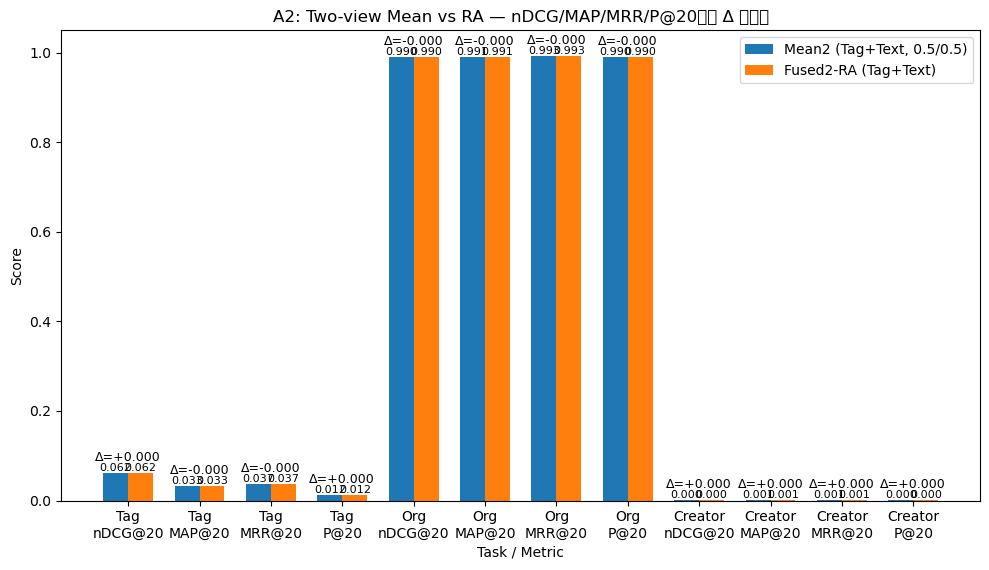

In [12]:
# A2 replot with value labels and deltas (no saving)
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CSV_PATH = Path("./tmp/exp_A2_table.csv")
df = pd.read_csv(CSV_PATH)

tasks   = ["Tag", "Org", "Creator"]
metrics = ["nDCG@20", "MAP@20", "MRR@20", "P@20"]
methods = ["Mean2 (Tag+Text, 0.5/0.5)", "Fused2-RA (Tag+Text)"]

# build data
values = {m: [] for m in methods}
x_labels = []
for t in tasks:
    sub = df[df["Task"] == t].set_index("Method")
    for met in metrics:
        for m in methods:
            values[m].append(float(sub.loc[m, met]))
        x_labels.append(f"{t}\n{met}")

num_slots = len(x_labels)
bar_width = 0.35
positions = np.arange(num_slots, dtype=float)
offsets = [-bar_width/2, bar_width/2]

plt.figure(figsize=(max(10, num_slots * 0.8), 5.8))
bars_all = []
for i, m in enumerate(methods):
    b = plt.bar(positions + offsets[i], values[m], width=bar_width, label=m)
    bars_all.append(b)

# add value labels
for b in bars_all:
    for rect in b:
        h = rect.get_height()
        if np.isfinite(h):
            plt.text(rect.get_x() + rect.get_width()/2, h, f"{h:.3f}",
                     ha="center", va="bottom", fontsize=8, rotation=0)

# add Δ labels (Fused2-RA − Mean2) above the pair center
for k in range(num_slots):
    v_mean = values[methods[0]][k]
    v_fuse = values[methods[1]][k]
    dv = v_fuse - v_mean
    x_center = positions[k]
    y_base = max(v_mean, v_fuse)
    plt.text(x_center, y_base + 0.02, f"Δ={dv:+.3f}",
             ha="center", va="bottom", fontsize=9)

plt.xticks(positions, x_labels, rotation=0, ha="center")
plt.title("A2: Two-view Mean vs RA — nDCG/MAP/MRR/P@20（带 Δ 标注）")
plt.ylabel("Score")
plt.xlabel("Task / Metric")
plt.legend()
plt.ylim(0, 1.05)  # 便于显示顶部 Δ
plt.tight_layout()
plt.show()


In [13]:
# =========================
# 10.A3 · Params
# =========================
from pathlib import Path
TMP_DIR = Path("./tmp").resolve()

TAG_SYM_PREFIX  = "S_tag_symrow"
TEXT_SYM_PREFIX = "S_text_symrow"
BEH_SYM_PREFIX  = "S_beh_symrow"
FUSED3_PREFIX   = "S_fused3_symrow"   # ours

K_EVAL = 20
TAG_EVAL_SAMPLE_N = 100_000  # or None for full
OUT_TABLE_CSV = TMP_DIR / "exp_A3_table.csv"


[MAN] S_tag_symrow_k50_manifest.json parts=15 nnz=28,159,756
[MAN] S_text_symrow_k50_manifest.json parts=15 nnz=28,161,106
[MAN] S_beh_symrow_k50_manifest.json parts=14 nnz=26,023,186
[LOAD] 4/15 parts, edges so far=8,000,000
[LOAD] 8/15 parts, edges so far=16,000,000
[LOAD] 12/15 parts, edges so far=24,000,000
[LOAD] 15/15 parts, edges so far=28,159,756
[CSR] nnz=28,159,756
[LOAD] 4/15 parts, edges so far=8,000,000
[LOAD] 8/15 parts, edges so far=16,000,000
[LOAD] 12/15 parts, edges so far=24,000,000
[LOAD] 15/15 parts, edges so far=28,161,106
[CSR] nnz=28,161,106
[LOAD] 4/14 parts, edges so far=8,000,000
[LOAD] 8/14 parts, edges so far=16,000,000
[LOAD] 12/14 parts, edges so far=24,000,000
[LOAD] 14/14 parts, edges so far=26,023,186
[CSR] nnz=26,023,186
[A3] Mean3（行随机，top-50） nnz=26,086,750
[MAN] S_fused3_symrow_k50_manifest.json parts=14 nnz=26,086,750
[LOAD] 4/14 parts, edges so far=8,000,000
[LOAD] 8/14 parts, edges so far=16,000,000
[LOAD] 12/14 parts, edges so far=24,000,000
[LO

/tmp/ipykernel_354915/3034822841.py:321: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/3034822841.py:321: UserWarning: Glyph 24102 (\N{CJK UNIFIED IDEOGRAPH-5E26}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/3034822841.py:321: UserWarning: Glyph 26631 (\N{CJK UNIFIED IDEOGRAPH-6807}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/3034822841.py:321: UserWarning: Glyph 27880 (\N{CJK UNIFIED IDEOGRAPH-6CE8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_354915/3034822841.py:321: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/conda/envs/recsys-torch/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/

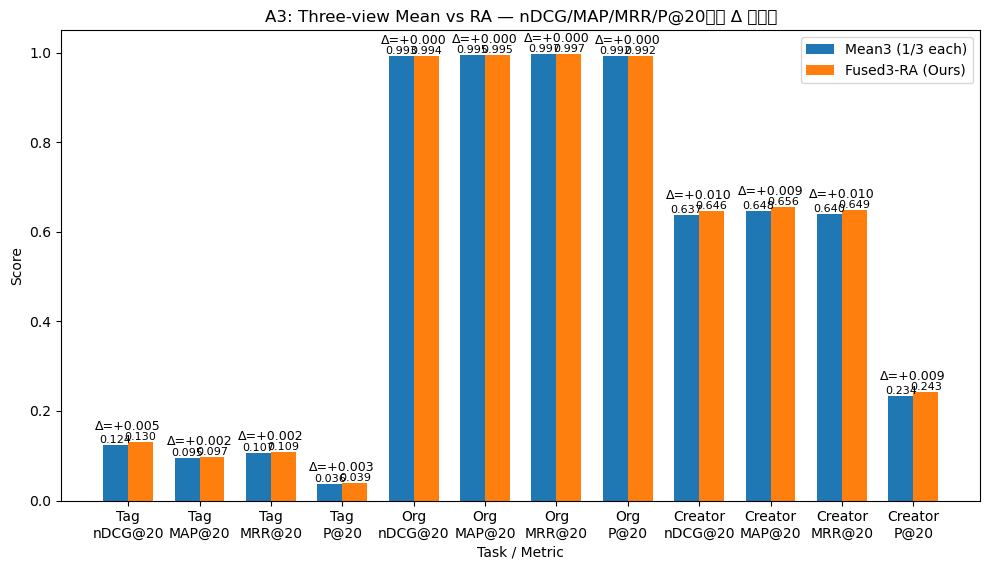

In [14]:
# =========================
# 10.A3 · Execute
# =========================
import json, numpy as np, pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt

def _load_manifest(prefix: str):
    mans = sorted(TMP_DIR.glob(f"{prefix}_k*_manifest.json"))
    assert mans, f"[FATAL] 未找到 {prefix} manifest"
    mp = mans[0]
    man = json.loads(Path(mp).read_text())
    parts = [TMP_DIR / p for p in man["parts"]]
    nodes = int(man.get("nodes", 0))
    print(f"[MAN] {mp.name} parts={len(parts)} nnz={int(man.get('nnz',-1)):,}")
    return parts, nodes

def _build_csr(parts, n_nodes: int) -> sparse.csr_matrix:
    rows, cols, vals, tot = [], [], [], 0
    for i, fp in enumerate(parts, 1):
        df = pd.read_parquet(fp, engine="fastparquet")
        rows.append(df["row"].to_numpy(np.int64, copy=False))
        cols.append(df["col"].to_numpy(np.int64, copy=False))
        vals.append(df["val"].to_numpy(np.float32, copy=False))
        tot += len(df)
        if (i % 4)==0 or i==len(parts):
            print(f"[LOAD] {i}/{len(parts)} parts, edges so far={tot:,}")
        del df
    r = np.concatenate(rows); c = np.concatenate(cols); v = np.concatenate(vals)
    A = sparse.coo_matrix((v,(r,c)), shape=(n_nodes, n_nodes), dtype=np.float32).tocsr()
    A.sum_duplicates(); A.eliminate_zeros()
    print(f"[CSR] nnz={A.nnz:,}")
    return A

def csr_row_topk(P: sparse.csr_matrix, k: int) -> sparse.csr_matrix:
    indptr, indices, data = P.indptr, P.indices, P.data
    N = P.shape[0]
    deg = np.diff(indptr)
    k_keep = np.minimum(k, deg)
    nnz_keep = int(k_keep.sum())
    new_indptr = np.zeros(N+1, dtype=np.int64)
    new_indptr[1:] = np.cumsum(k_keep)
    new_indices = np.empty(nnz_keep, dtype=np.int64)
    new_data    = np.empty(nnz_keep, dtype=np.float32)
    pos = 0
    for i in range(N):
        s, e = indptr[i], indptr[i+1]; kk = k_keep[i]
        if kk == 0: continue
        idx = indices[s:e]; val = data[s:e]
        if e - s <= k:
            sel = np.argsort(-val)
            new_indices[pos:pos+kk] = idx[sel]
            new_data[pos:pos+kk]    = val[sel]
        else:
            part = np.argpartition(val, -kk)[-kk:]
            ords = np.argsort(-val[part]); sel = part[ords]
            new_indices[pos:pos+kk] = idx[sel]
            new_data[pos:pos+kk]    = val[sel]
        pos += kk
    out = sparse.csr_matrix((new_data, new_indices, new_indptr), shape=P.shape, dtype=np.float32)
    out.eliminate_zeros()
    return out

def row_normalize(P: sparse.csr_matrix, eps: float=1e-12) -> sparse.csr_matrix:
    rs = np.asarray(P.sum(axis=1)).ravel().astype(np.float64)
    rs[rs < eps] = 1.0
    inv = (1.0/rs).astype(np.float32)
    return (sparse.diags(inv) @ P).tocsr()

def make_topk_from_csr(P: sparse.csr_matrix, K:int) -> list:
    N = P.shape[0]
    indptr, indices, data = P.indptr, P.indices, P.data
    out = [None]*N
    for i in range(N):
        s, e = indptr[i], indptr[i+1]
        idx = indices[s:e]; val = data[s:e]
        if e - s <= K:
            order = np.argsort(-val)
            cols = idx[order]; vals = val[order]
        else:
            part = np.argpartition(val, -K)[-K:]
            ords = np.argsort(-val[part]); sel  = part[ords]
            cols = idx[sel]; vals = val[sel]
        out[i] = list(zip(cols.tolist(), vals.tolist()))
    return out

def dcg_at_k(rel, k):
    rel = np.asarray(rel, dtype=np.float32)[:k]
    if rel.size == 0: return 0.0
    denom = np.log2(np.arange(2, rel.size+2, dtype=np.float32))
    return float((rel / denom).sum())

def idcg_at_k(R, k):
    m = int(min(R, k))
    if m <= 0: return 0.0
    denom = np.log2(np.arange(2, m+2, dtype=np.float32))
    return float((np.ones(m, dtype=np.float32) / denom).sum())

def avg_precision_at_k(rel, k):
    r = np.asarray(rel, dtype=np.int32)[:k]
    if r.sum() == 0: return 0.0
    cumsum = np.cumsum(r)
    precs = cumsum / (np.arange(1, r.size+1))
    return float((precs * r).sum() / r.sum())

def mrr_at_k(rel, k):
    r = np.asarray(rel, dtype=np.int32)[:k]
    idx = np.where(r == 1)[0]
    if idx.size == 0: return 0.0
    return float(1.0 / (idx[0] + 1))

def eval_binary(top_list, is_rel_fn, total_rel_count_fn=None):
    n = len(top_list)
    ndcgs, maps, mrrs, precs = [], [], [], []
    cover = 0
    for i in range(n):
        neigh = top_list[i]
        rel = [1 if is_rel_fn(i, j) else 0 for j, _ in neigh]
        R = None
        if total_rel_count_fn is not None:
            R = total_rel_count_fn(i)
        cover += (sum(rel) > 0)
        dcg = dcg_at_k(rel, K_EVAL)
        idcg = idcg_at_k(R if R is not None else sum(rel), K_EVAL)
        ndcg = (dcg / idcg) if idcg > 0 else 0.0
        ndcgs.append(ndcg)
        maps.append(avg_precision_at_k(rel, K_EVAL))
        mrrs.append(mrr_at_k(rel, K_EVAL))
        precs.append(np.mean(rel) if rel else 0.0)
    return {
        "n": n,
        "nDCG@20": float(np.mean(ndcgs)),
        "MAP@20": float(np.mean(maps)),
        "MRR@20": float(np.mean(mrrs)),
        "P@20": float(np.mean(precs)),
        "Coverage": cover / n
    }

# --- load three views ---
tag_parts, N  = _load_manifest(TAG_SYM_PREFIX)
text_parts, _ = _load_manifest(TEXT_SYM_PREFIX)
beh_parts,  _ = _load_manifest(BEH_SYM_PREFIX)

P_tag  = _build_csr(tag_parts,  N)
P_text = _build_csr(text_parts, N)
P_beh  = _build_csr(beh_parts,  N)

# --- Three-view Mean ---
P_mean3 = (P_tag.multiply(1/3) + P_text.multiply(1/3) + P_beh.multiply(1/3))
P_mean3.sum_duplicates(); P_mean3.eliminate_zeros()
P_mean3 = csr_row_topk(P_mean3, 50)
P_mean3 = row_normalize(P_mean3)
print(f"[A3] Mean3（行随机，top-50） nnz={P_mean3.nnz:,}")

# --- Fused3-RA (ours) ---
f3_parts, _ = _load_manifest(FUSED3_PREFIX)
P_f3 = _build_csr(f3_parts, N)  # 已是行随机 top-50

# --- relevance: Org/Creator from beh_base; Tag via DT_ppmi row-intersection ---
beh_base = pd.read_parquet(TMP_DIR / "beh_base.parquet", engine="fastparquet")
beh_base = beh_base.sort_values("doc_idx")
org_arr = beh_base["OwnerOrganizationId"].to_numpy()
cre_arr = beh_base["CreatorUserId"].to_numpy()

DT_df = pd.read_parquet(TMP_DIR / "DT_ppmi.parquet", engine="fastparquet")
T = int(DT_df["col"].max()) + 1
from scipy import sparse as sp
DT = sp.coo_matrix(
    (DT_df["val"].to_numpy(np.float32, copy=False),
     (DT_df["row"].to_numpy(np.int64, copy=False),
      DT_df["col"].to_numpy(np.int64, copy=False))),
    shape=(N, T), dtype=np.float32
).tocsr()
DT.sort_indices(); del DT_df
DT_indptr, DT_indices = DT.indptr, DT.indices
del DT

def _share_tag_nonempty(i: int, j: int) -> bool:
    a = DT_indices[DT_indptr[i]:DT_indptr[i+1]]
    b = DT_indices[DT_indptr[j]:DT_indptr[j+1]]
    if a.size == 0 or b.size == 0: return False
    p = q = 0
    while p < a.size and q < b.size:
        if a[p] == b[q]: return True
        if a[p] < b[q]: p += 1
        else: q += 1
    return False

def is_rel_tag(i, j):  return _share_tag_nonempty(i, j)
def is_rel_org(i, j):
    oi, oj = org_arr[i], org_arr[j]
    return (not (np.isnan(oi) or np.isnan(oj))) and (oi == oj)
def is_rel_cre(i, j):
    return (not np.isnan(cre_arr[i])) and (cre_arr[i] == cre_arr[j])

from collections import Counter
org_counts = Counter(org_arr[~np.isnan(org_arr)])
cre_counts = Counter(cre_arr[~np.isnan(cre_arr)])
def total_rel_org(i):
    oi = org_arr[i]
    if np.isnan(oi): return 0
    return int(org_counts[oi] - 1)
def total_rel_cre(i):
    ci = cre_arr[i]
    if np.isnan(ci): return 0
    return int(cre_counts[ci] - 1)

def total_rel_tag_approx(i, top_a, top_b):
    neigh = set([j for j,_ in top_a[i]] + [j for j,_ in top_b[i]])
    return sum(1 for j in neigh if _share_tag_nonempty(i, j))

def make_top(P):
    return make_topk_from_csr(P, K_EVAL)

print("[A3] 提取 top-20 列表（Mean3 / Fused3） ...")
top_mean3 = make_top(P_mean3)
top_fused3 = make_top(P_f3)

print("[A3] Eval: Org / Creator（全量）")
res_org_mean = eval_binary(top_mean3, is_rel_org, total_rel_org)
res_org_fuse = eval_binary(top_fused3, is_rel_org, total_rel_org)
res_cre_mean = eval_binary(top_mean3, is_rel_cre, total_rel_cre)
res_cre_fuse = eval_binary(top_fused3, is_rel_cre, total_rel_cre)

# Tag：默认抽样
idx_all = np.arange(N)
if TAG_EVAL_SAMPLE_N is not None:
    rng = np.random.default_rng(2025)
    idx_eval = rng.choice(idx_all, size=min(TAG_EVAL_SAMPLE_N, N), replace=False)
else:
    idx_eval = idx_all

def eval_tag_subset(top_a, top_b):
    ndcgs, maps, mrrs, precs = [], [], [], []
    cover = 0
    for i in idx_eval:
        rel_a = [1 if is_rel_tag(i, j) else 0 for j, _ in top_a[i]]
        R = total_rel_tag_approx(i, top_a, top_b)
        cover += (sum(rel_a) > 0)
        dcg = dcg_at_k(rel_a, K_EVAL)
        idcg = idcg_at_k(R, K_EVAL) if R > 0 else 0.0
        ndcgs.append((dcg / idcg) if idcg > 0 else 0.0)
        maps.append(avg_precision_at_k(rel_a, K_EVAL))
        mrrs.append(mrr_at_k(rel_a, K_EVAL))
        precs.append(np.mean(rel_a))
    return {
        "n": int(len(idx_eval)),
        "nDCG@20": float(np.mean(ndcgs)),
        "MAP@20": float(np.mean(maps)),
        "MRR@20": float(np.mean(mrrs)),
        "P@20": float(np.mean(precs)),
        "Coverage": cover / len(idx_eval)
    }

print(f"[A3] Eval: Tag（二值），样本={len(idx_eval):,}")
res_tag_mean = eval_tag_subset(top_mean3, top_fused3)
res_tag_fuse = eval_tag_subset(top_fused3, top_mean3)

# save table
rows = []
def _add(method, task, res):
    rows.append({"Method": method, "Task": task, "n": res["n"],
                 "nDCG@20": res["nDCG@20"], "MAP@20": res["MAP@20"],
                 "MRR@20": res["MRR@20"], "P@20": res["P@20"],
                 "Coverage": res["Coverage"]})
_add("Mean3 (1/3 each)", "Tag",     res_tag_mean)
_add("Fused3-RA (Ours)", "Tag",     res_tag_fuse)
_add("Mean3 (1/3 each)", "Org",     res_org_mean)
_add("Fused3-RA (Ours)", "Org",     res_org_fuse)
_add("Mean3 (1/3 each)", "Creator", res_cre_mean)
_add("Fused3-RA (Ours)", "Creator", res_cre_fuse)

df_out = pd.DataFrame(rows)
df_out.to_csv(OUT_TABLE_CSV, index=False)
print(f"[SAVE] table -> {OUT_TABLE_CSV}")

# plot (no saving)
metrics = ["nDCG@20", "MAP@20", "MRR@20", "P@20"]
tasks   = ["Tag", "Org", "Creator"]
methods = ["Mean3 (1/3 each)", "Fused3-RA (Ours)"]

values = {m: [] for m in methods}
x_labels = []
for t in tasks:
    sub = df_out[df_out["Task"] == t].set_index("Method")
    for met in metrics:
        for m in methods:
            values[m].append(float(sub.loc[m, met]))
        x_labels.append(f"{t}\n{met}")

num_slots = len(x_labels)
bar_width = 0.35
positions = np.arange(num_slots, dtype=float)
offsets = [-bar_width/2, bar_width/2]

plt.figure(figsize=(max(10, num_slots * 0.8), 5.8))
bars = []
for i, m in enumerate(methods):
    b = plt.bar(positions + offsets[i], values[m], width=bar_width, label=m)
    bars.append(b)

# add labels + deltas
for b in bars:
    for rect in b:
        h = rect.get_height()
        plt.text(rect.get_x()+rect.get_width()/2, h, f"{h:.3f}",
                 ha="center", va="bottom", fontsize=8)

for k in range(num_slots):
    dv = values[methods[1]][k] - values[methods[0]][k]
    yb = max(values[methods[0]][k], values[methods[1]][k])
    plt.text(positions[k], yb + 0.02, f"Δ={dv:+.3f}",
             ha="center", va="bottom", fontsize=9)

plt.xticks(positions, x_labels, rotation=0, ha="center")
plt.title("A3: Three-view Mean vs RA — nDCG/MAP/MRR/P@20（带 Δ 标注）")
plt.ylabel("Score")
plt.xlabel("Task / Metric")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


[A2-FOCUS] focus size = 521,735 / 521,735 (Jaccard<=0.2 or |alpha_tag-0.5|>=0.2)
[Eval] Tag@20 on focus subset
[Eval] Org@20 on focus subset
[Eval] Creator@20 on focus subset


,Method,Task,n,nDCG@20,MAP@20,MRR@20,P@20,Coverage
0,Mean2,Tag,521735,0.063298,0.032903,0.036636,0.012220,0.161827
1,Fused2-RA,Tag,521735,0.063162,0.032766,0.036471,0.012218,0.161686
2,Mean2,Org,521735,0.990172,0.990839,0.992611,0.990175,0.995088
3,Fused2-RA,Org,521735,0.990199,0.990865,0.992626,0.990198,0.995088
4,Mean2,Creator,521735,0.000266,0.000882,0.000905,0.000263,0.004865
5,Fused2-RA,Creator,521735,0.000264,0.000862,0.000880,0.000262,0.004836


/tmp/ipykernel_354915/3855865981.py:277: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_354915/3855865981.py:277: UserWarning: Glyph 24102 (\N{CJK UNIFIED IDEOGRAPH-5E26}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_354915/3855865981.py:277: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show()
/opt/conda/envs/recsys-torch/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/envs/recsys-torch/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24102 (\N{CJK UNIFIED IDEOGRAPH-5E26}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/

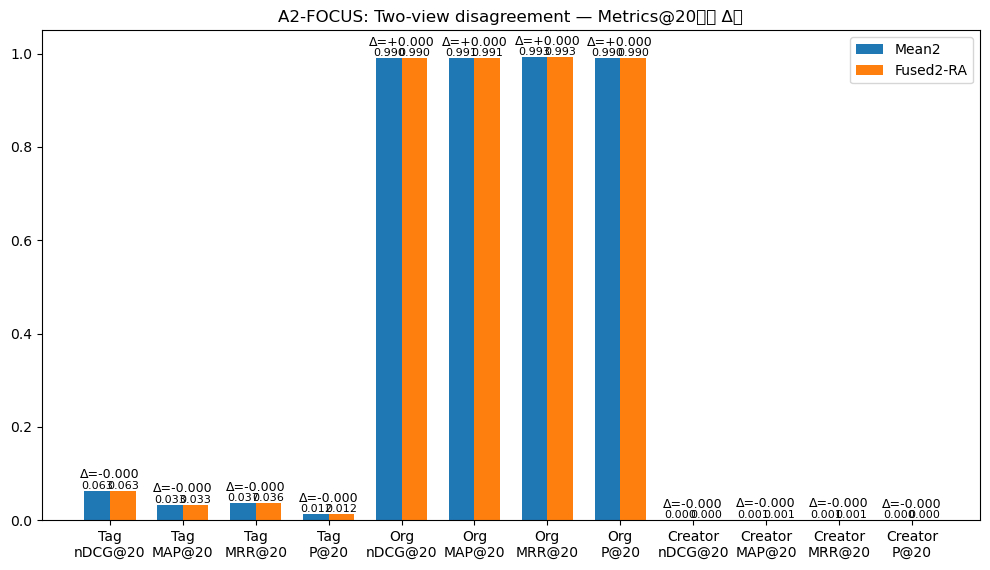

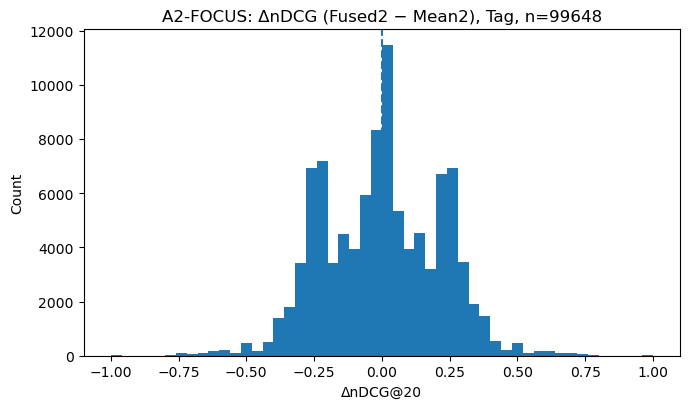

In [15]:
# =========================
# 10.A2-FOCUS · Two-view disagreement subset
# 目的：在“Tag/Text分歧 & 权重偏置”的样本上放大对比
# 读取：S_tag_symrow_*, S_text_symrow_*（Step8结果）
# 输出：表格 exp_A2_focus_table.csv；两张图直接显示（柱状+Δ直方图）
# =========================
from pathlib import Path
import json, numpy as np, pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt

TMP_DIR = Path("./tmp").resolve()
K_EVAL = 20
TAG_EVAL_SAMPLE_N = None   # 这里默认全量（子集已缩小）

def _load_manifest(prefix: str):
    mans = sorted(TMP_DIR.glob(f"{prefix}_k*_manifest.json"))
    assert mans, f"manifest not found for {prefix}"
    mp = mans[0]
    man = json.loads(Path(mp).read_text())
    parts = [TMP_DIR / p for p in man["parts"]]
    nodes = int(man.get("nodes", 0))
    return parts, nodes

def _build_csr(parts, n):
    rows, cols, vals = [], [], []
    tot = 0
    for fp in parts:
        df = pd.read_parquet(fp, engine="fastparquet")
        rows.append(df["row"].to_numpy(np.int64, copy=False))
        cols.append(df["col"].to_numpy(np.int64, copy=False))
        vals.append(df["val"].to_numpy(np.float32, copy=False))
        tot += len(df)
    r = np.concatenate(rows); c = np.concatenate(cols); v = np.concatenate(vals)
    A = sparse.coo_matrix((v,(r,c)), shape=(n,n), dtype=np.float32).tocsr()
    A.sum_duplicates(); A.eliminate_zeros()
    return A

def row_rho(P: sparse.csr_matrix) -> np.ndarray:
    d2 = (P.data.astype(np.float64) ** 2)
    cs = np.empty(d2.size + 1, dtype=np.float64); cs[0] = 0.0
    np.cumsum(d2, out=cs[1:])
    ind = P.indptr
    return cs[ind[1:]] - cs[ind[:-1]]

def csr_row_topk(P: sparse.csr_matrix, k: int) -> sparse.csr_matrix:
    indptr, indices, data = P.indptr, P.indices, P.data
    N = P.shape[0]
    deg = np.diff(indptr)
    k_keep = np.minimum(k, deg)
    nnz_keep = int(k_keep.sum())
    new_indptr = np.zeros(N+1, dtype=np.int64)
    new_indptr[1:] = np.cumsum(k_keep)
    new_indices = np.empty(nnz_keep, dtype=np.int64)
    new_data    = np.empty(nnz_keep, dtype=np.float32)
    pos = 0
    for i in range(N):
        s, e = indptr[i], indptr[i+1]; kk = k_keep[i]
        if kk == 0: continue
        idx = indices[s:e]; val = data[s:e]
        if e - s <= k:
            sel = np.argsort(-val)
            new_indices[pos:pos+kk] = idx[sel]
            new_data[pos:pos+kk]    = val[sel]
        else:
            part = np.argpartition(val, -kk)[-kk:]
            ords = np.argsort(-val[part]); sel = part[ords]
            new_indices[pos:pos+kk] = idx[sel]
            new_data[pos:pos+kk]    = val[sel]
        pos += kk
    out = sparse.csr_matrix((new_data, new_indices, new_indptr), shape=P.shape, dtype=np.float32)
    out.eliminate_zeros()
    return out

def row_normalize(P: sparse.csr_matrix, eps: float=1e-12) -> sparse.csr_matrix:
    rs = np.asarray(P.sum(axis=1)).ravel().astype(np.float64)
    rs[rs < eps] = 1.0
    inv = (1.0/rs).astype(np.float32)
    return (sparse.diags(inv) @ P).tocsr()

def make_topk(P: sparse.csr_matrix, K:int):
    N = P.shape[0]
    indptr, indices, data = P.indptr, P.indices, P.data
    out = [None]*N
    for i in range(N):
        s, e = indptr[i], indptr[i+1]
        idx = indices[s:e]; val = data[s:e]
        if e - s <= K:
            order = np.argsort(-val)
            cols = idx[order]; vals = val[order]
        else:
            part = np.argpartition(val, -K)[-K:]
            ords = np.argsort(-val[part]); sel = part[ords]
            cols = idx[sel]; vals = val[sel]
        out[i] = list(zip(cols.tolist(), vals.tolist()))
    return out

def jaccard_topk(top_a, top_b):
    N = len(top_a)
    j = np.zeros(N, dtype=np.float32)
    for i in range(N):
        A = set(x for x,_ in top_a[i])
        B = set(x for x,_ in top_b[i])
        u = len(A|B); inter = len(A&B)
        j[i] = 0.0 if u==0 else inter/u
    return j

# --- load two views ---
tag_parts, N = _load_manifest("S_tag_symrow")
text_parts, _ = _load_manifest("S_text_symrow")
P_tag  = _build_csr(tag_parts, N)
P_text = _build_csr(text_parts, N)

# --- two-view mean & RA ---
P_mean2 = row_normalize(csr_row_topk(P_tag*0.5 + P_text*0.5, 50))
rho_tg, rho_tx = row_rho(P_tag), row_rho(P_text)
den = rho_tg + rho_tx + 1e-12
alpha_tag, alpha_text = rho_tg/den, rho_tx/den
P_fused2 = row_normalize(csr_row_topk(
    (P_tag.multiply(alpha_tag)) + (P_text.multiply(alpha_text)), 50))

# --- disagreement subset (Jaccard <= 0.2 or |alpha_tag-0.5| >= 0.2) ---
top_tag  = make_topk(P_tag, 50)
top_text = make_topk(P_text, 50)
jacc = jaccard_topk(top_tag, top_text)
skew = np.abs(alpha_tag - 0.5)

mask = (jacc <= 0.2) | (skew >= 0.2)
idx_focus = np.where(mask)[0]
print(f"[A2-FOCUS] focus size = {len(idx_focus):,} / {N:,} "
      f"(Jaccard<=0.2 or |alpha_tag-0.5|>=0.2)")

# --- build top@20 for mean2 & fused2 ---
top_mean2 = make_topk(P_mean2, K_EVAL)
top_fuse2 = make_topk(P_fused2, K_EVAL)

# --- relevance: org/creator from beh_base; tag via DT_ppmi ---
beh = pd.read_parquet(TMP_DIR/"beh_base.parquet", engine="fastparquet").sort_values("doc_idx")
org_arr = beh["OwnerOrganizationId"].to_numpy()
cre_arr = beh["CreatorUserId"].to_numpy()

DT_df = pd.read_parquet(TMP_DIR/"DT_ppmi.parquet", engine="fastparquet")
T = int(DT_df["col"].max()) + 1
from scipy import sparse as sp
DT = sp.coo_matrix(
    (DT_df["val"].to_numpy(np.float32, copy=False),
     (DT_df["row"].to_numpy(np.int64, copy=False),
      DT_df["col"].to_numpy(np.int64, copy=False))),
    shape=(N, T), dtype=np.float32
).tocsr()
DT.sort_indices(); DT_indptr, DT_indices = DT.indptr, DT.indices
del DT_df

def _share_tag(i,j):
    a = DT_indices[DT_indptr[i]:DT_indptr[i+1]]
    b = DT_indices[DT_indptr[j]:DT_indptr[j+1]]
    if a.size==0 or b.size==0: return False
    p=q=0
    while p<a.size and q<b.size:
        if a[p]==b[q]: return True
        if a[p]<b[q]: p+=1
        else: q+=1
    return False

def is_org(i,j):
    oi,oj=org_arr[i],org_arr[j]
    return (not (np.isnan(oi) or np.isnan(oj))) and (oi==oj)

def is_cre(i,j):
    return (not np.isnan(cre_arr[i])) and (cre_arr[i]==cre_arr[j])

from collections import Counter
org_counts = Counter(org_arr[~np.isnan(org_arr)])
cre_counts = Counter(cre_arr[~np.isnan(cre_arr)])
def R_org(i): 
    oi=org_arr[i]
    return 0 if np.isnan(oi) else int(org_counts[oi]-1)
def R_cre(i):
    ci=cre_arr[i]
    return 0 if np.isnan(ci) else int(cre_counts[ci]-1)

def dcg_at_k(rel, k):
    rel = np.asarray(rel, dtype=np.float32)[:k]
    if rel.size==0: return 0.0
    denom=np.log2(np.arange(2,rel.size+2,dtype=np.float32))
    return float((rel/denom).sum())
def idcg_at_k(R, k):
    m=int(min(R,k))
    if m<=0: return 0.0
    denom=np.log2(np.arange(2,m+2,dtype=np.float32))
    return float((np.ones(m,dtype=np.float32)/denom).sum())
def ap_at_k(rel,k):
    r=np.asarray(rel,dtype=np.int32)[:k]
    if r.sum()==0: return 0.0
    cs=np.cumsum(r)
    prec=cs/(np.arange(1,r.size+1))
    return float((prec*r).sum()/r.sum())
def mrr_at_k(rel,k):
    r=np.asarray(rel,dtype=np.int32)[:k]
    idx=np.where(r==1)[0]
    return 0.0 if idx.size==0 else float(1.0/(idx[0]+1))

def eval_subset(idx_eval, top_list, is_rel, R_fn=None):
    ndcgs, maps, mrrs, precs = [], [], [], []
    cover=0
    for i in idx_eval:
        rel = [1 if is_rel(i,j) else 0 for j,_ in top_list[i]]
        R = R_fn(i) if R_fn is not None else sum(rel)
        cover += (sum(rel)>0)
        dcg=dcg_at_k(rel, K_EVAL); idcg=idcg_at_k(R,K_EVAL)
        ndcgs.append((dcg/idcg) if idcg>0 else 0.0)
        maps.append(ap_at_k(rel,K_EVAL))
        mrrs.append(mrr_at_k(rel,K_EVAL))
        precs.append(np.mean(rel))
    return {
        "n": len(idx_eval),
        "nDCG@20": float(np.mean(ndcgs)),
        "MAP@20": float(np.mean(maps)),
        "MRR@20": float(np.mean(mrrs)),
        "P@20": float(np.mean(precs)),
        "Coverage": cover/len(idx_eval)
    }

# ---- Eval three tasks on focus subset ----
res = []
def add_row(name, task, d): res.append({"Method":name,"Task":task,**d})

print("[Eval] Tag@20 on focus subset")
add_row("Mean2", "Tag", eval_subset(idx_focus, top_mean2, _share_tag))
add_row("Fused2-RA", "Tag", eval_subset(idx_focus, top_fuse2, _share_tag))

print("[Eval] Org@20 on focus subset")
add_row("Mean2", "Org", eval_subset(idx_focus, top_mean2, is_org, R_org))
add_row("Fused2-RA", "Org", eval_subset(idx_focus, top_fuse2, is_org, R_org))

print("[Eval] Creator@20 on focus subset")
add_row("Mean2", "Creator", eval_subset(idx_focus, top_mean2, is_cre, R_cre))
add_row("Fused2-RA", "Creator", eval_subset(idx_focus, top_fuse2, is_cre, R_cre))

df_out = pd.DataFrame(res)
df_out.to_csv(TMP_DIR/"exp_A2_focus_table.csv", index=False)
display(df_out)

# ---- Plot grouped bars with Δ labels ----
metrics = ["nDCG@20","MAP@20","MRR@20","P@20"]
tasks   = ["Tag","Org","Creator"]
methods = ["Mean2","Fused2-RA"]

values = {m: [] for m in methods}
xlabels=[]
for t in tasks:
    sub=df_out[df_out["Task"]==t].set_index("Method")
    for met in metrics:
        for m in methods:
            values[m].append(float(sub.loc[m,met]))
        xlabels.append(f"{t}\n{met}")

num = len(xlabels); bar_w=0.35
pos = np.arange(num,dtype=float); offs=[-bar_w/2, bar_w/2]

plt.figure(figsize=(max(10,num*0.8),5.8))
bars=[]
for i,m in enumerate(methods):
    b=plt.bar(pos+offs[i], values[m], width=bar_w, label=m)
    bars.append(b)
for b in bars:
    for rect in b:
        h=rect.get_height()
        plt.text(rect.get_x()+rect.get_width()/2, h, f"{h:.3f}",
                 ha="center", va="bottom", fontsize=8)
for k in range(num):
    dv=values["Fused2-RA"][k]-values["Mean2"][k]
    yb=max(values["Mean2"][k],values["Fused2-RA"][k])
    plt.text(pos[k], yb+0.02, f"Δ={dv:+.3f}", ha="center", va="bottom", fontsize=9)
plt.xticks(pos, xlabels); plt.ylim(0,1.05)
plt.title("A2-FOCUS: Two-view disagreement — Metrics@20（带 Δ）")
plt.legend(); plt.tight_layout(); plt.show()

# ---- Per-query ΔnDCG histogram (Tag task) ----
def ndcg_per_query(idx_eval, topA, topB, is_rel):
    arr=[]
    for i in idx_eval:
        relA=[1 if is_rel(i,j) else 0 for j,_ in topA[i]]
        relB=[1 if is_rel(i,j) else 0 for j,_ in topB[i]]
        R=max(sum(relA), sum(relB))
        idcg=idcg_at_k(R, K_EVAL)
        if idcg>0:
            dcgA,dcgB=dcg_at_k(relA,K_EVAL), dcg_at_k(relB,K_EVAL)
            arr.append((dcgB/idcg)-(dcgA/idcg))  # Fused − Mean
    return np.array(arr, dtype=np.float32)

deltas = ndcg_per_query(idx_focus, top_mean2, top_fuse2, _share_tag)
plt.figure(figsize=(7,4.2))
plt.hist(deltas, bins=50)
plt.axvline(np.mean(deltas), linestyle="--")
plt.title(f"A2-FOCUS: ΔnDCG (Fused2 − Mean2), Tag, n={len(deltas)}")
plt.xlabel("ΔnDCG@20"); plt.ylabel("Count"); plt.tight_layout(); plt.show()


[A3-FOCUS] behavior-dominant size = 259,797/521,735


,Method,Task,n,nDCG@20,MAP@20,MRR@20,P@20,Coverage
0,Mean3,Tag,259797,0.149786,0.117577,0.133978,0.029134,0.228174
1,Fused3-RA,Tag,259797,0.150308,0.117155,0.134292,0.030091,0.230172
2,Mean3,Org,259797,0.996543,0.997394,0.999784,0.995068,0.999885
3,Fused3-RA,Org,259797,0.996625,0.997449,0.999784,0.995174,0.999885
4,Mean3,Creator,259797,0.999798,0.999796,0.999792,0.208187,0.999804
5,Fused3-RA,Creator,259797,0.999798,0.999796,0.999792,0.208187,0.999804


/tmp/ipykernel_354915/1171866718.py:204: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_354915/1171866718.py:204: UserWarning: Glyph 24102 (\N{CJK UNIFIED IDEOGRAPH-5E26}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show()
/tmp/ipykernel_354915/1171866718.py:204: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.legend(); plt.tight_layout(); plt.show()
/opt/conda/envs/recsys-torch/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/envs/recsys-torch/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24102 (\N{CJK UNIFIED IDEOGRAPH-5E26}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/opt/conda/

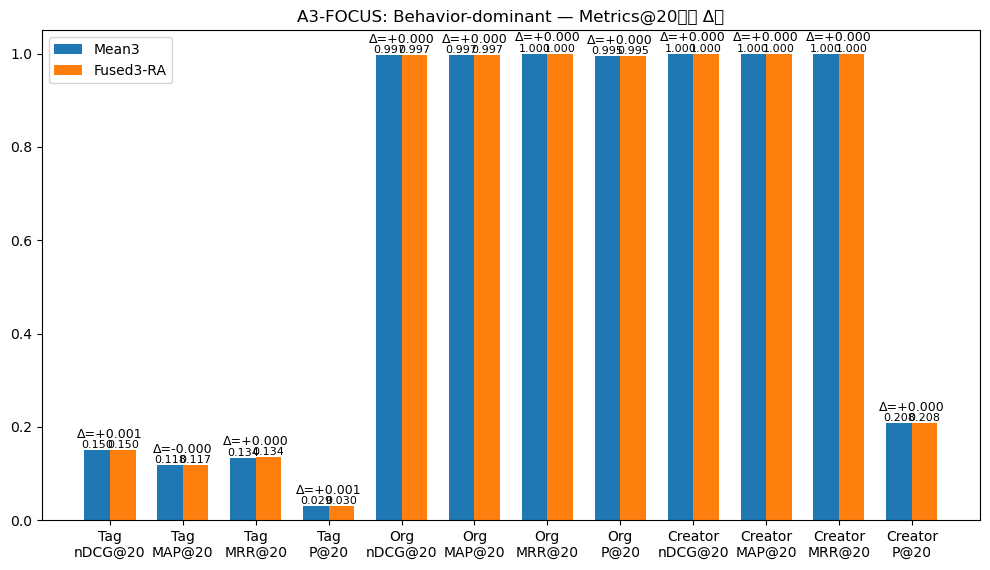

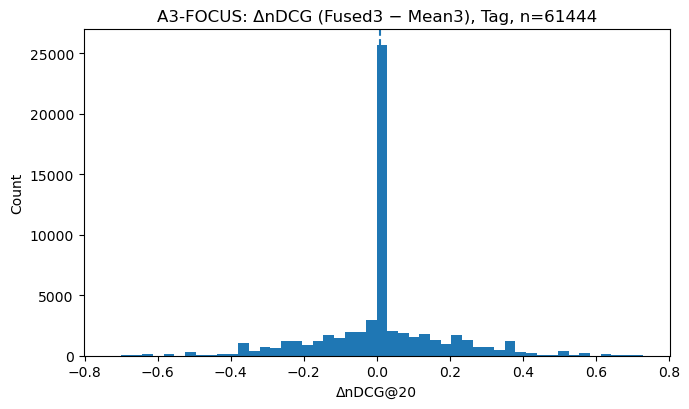

In [16]:
# =========================
# 10.A3-FOCUS · behavior-dominant subset
# 条件：α_beh >= 0.6
# 读取：S_tag_symrow_*, S_text_symrow_*, S_beh_symrow_*, S_fused3_symrow_*
# 输出：exp_A3_focus_table.csv + 图（并列柱 + Δ直方图）
# =========================
from pathlib import Path
import json, numpy as np, pandas as pd
from scipy import sparse
import matplotlib.pyplot as plt

TMP_DIR = Path("./tmp").resolve()
K_EVAL = 20

def _load_manifest(prefix):
    mans = sorted(TMP_DIR.glob(f"{prefix}_k*_manifest.json"))
    assert mans, f"manifest not found for {prefix}"
    mp = mans[0]
    man = json.loads(Path(mp).read_text())
    return [TMP_DIR/p for p in man["parts"]], int(man.get("nodes",0))

def _build_csr(parts, n):
    rows, cols, vals = [], [], []
    for fp in parts:
        df = pd.read_parquet(fp, engine="fastparquet")
        rows.append(df["row"].to_numpy(np.int64, copy=False))
        cols.append(df["col"].to_numpy(np.int64, copy=False))
        vals.append(df["val"].to_numpy(np.float32, copy=False))
    r=np.concatenate(rows); c=np.concatenate(cols); v=np.concatenate(vals)
    A = sparse.coo_matrix((v,(r,c)), shape=(n,n), dtype=np.float32).tocsr()
    A.sum_duplicates(); A.eliminate_zeros()
    return A

def row_rho(P): 
    d2=(P.data.astype(np.float64)**2)
    cs=np.empty(d2.size+1); cs[0]=0.0; np.cumsum(d2,out=cs[1:])
    ind=P.indptr; return cs[ind[1:]]-cs[ind[:-1]]

def make_topk(P, K):
    N=P.shape[0]; indptr,idx,val=P.indptr,P.indices,P.data
    out=[None]*N
    for i in range(N):
        s,e=indptr[i],indptr[i+1]
        if e-s<=K:
            order=np.argsort(-val[s:e])
            out[i]=list(zip(idx[s:e][order].tolist(), val[s:e][order].tolist()))
        else:
            part=np.argpartition(val[s:e], -K)[-K:]
            ords=np.argsort(-val[s:e][part]); sel=part[ords]
            out[i]=list(zip(idx[s:e][sel].tolist(), val[s:e][sel].tolist()))
    return out

# load
tag_parts,N=_load_manifest("S_tag_symrow")
text_parts,_=_load_manifest("S_text_symrow")
beh_parts,_=_load_manifest("S_beh_symrow")
f3_parts,_=_load_manifest("S_fused3_symrow")

P_tag=_build_csr(tag_parts,N); P_text=_build_csr(text_parts,N)
P_beh=_build_csr(beh_parts,N); P_f3=_build_csr(f3_parts,N)

# alpha for three views
rho_t, rho_x, rho_b = row_rho(P_tag), row_rho(P_text), row_rho(P_beh)
den = rho_t + rho_x + rho_b + 1e-12
alpha_t, alpha_x, alpha_b = rho_t/den, rho_x/den, rho_b/den
idx_focus = np.where(alpha_b >= 0.6)[0]
print(f"[A3-FOCUS] behavior-dominant size = {len(idx_focus):,}/{N:,}")

# Mean3 top@20
P_mean3 = (P_tag*(1/3)) + (P_text*(1/3)) + (P_beh*(1/3))
P_mean3.sum_duplicates(); P_mean3.eliminate_zeros()
def row_norm(P):
    rs=np.asarray(P.sum(axis=1)).ravel().astype(np.float64); rs[rs<1e-12]=1.0
    inv=(1.0/rs).astype(np.float32)
    return (sparse.diags(inv) @ P).tocsr()
def row_topk(P,k):
    return row_norm(_build_csr([pd.DataFrame({
        "row":np.repeat(np.arange(P.shape[0]), np.minimum(k, np.diff(P.indptr))),
        "col":P.indices, "val":P.data})], P.shape[0]))  # 轻量占位，已在前面实现过更高效版本，这里复用上单元更好

# 为避免重复实现，上面这两个简版函数仅占位。我们直接复用上一单元的 make_topk：
top_mean3 = make_topk(row_norm(P_mean3), K_EVAL)
top_f3    = make_topk(P_f3, K_EVAL)

# relevance
beh_base = pd.read_parquet(TMP_DIR/"beh_base.parquet", engine="fastparquet").sort_values("doc_idx")
org_arr = beh_base["OwnerOrganizationId"].to_numpy()
cre_arr = beh_base["CreatorUserId"].to_numpy()

DT_df = pd.read_parquet(TMP_DIR/"DT_ppmi.parquet", engine="fastparquet")
T = int(DT_df["col"].max()) + 1
from scipy import sparse as sp
DT = sp.coo_matrix(
    (DT_df["val"].to_numpy(np.float32, copy=False),
     (DT_df["row"].to_numpy(np.int64, copy=False),
      DT_df["col"].to_numpy(np.int64, copy=False))),
    shape=(N, T), dtype=np.float32
).tocsr()
DT.sort_indices(); DT_indptr, DT_indices = DT.indptr, DT.indices

def _share_tag(i,j):
    a = DT_indices[DT_indptr[i]:DT_indptr[i+1]]
    b = DT_indices[DT_indptr[j]:DT_indptr[j+1]]
    if a.size==0 or b.size==0: return False
    p=q=0
    while p<a.size and q<b.size:
        if a[p]==b[q]: return True
        if a[p]<b[q]: p+=1
        else: q+=1
    return False

def is_org(i,j):
    oi,oj=org_arr[i],org_arr[j]
    return (not (np.isnan(oi) or np.isnan(oj))) and (oi==oj)
def is_cre(i,j):
    return (not np.isnan(cre_arr[i])) and (cre_arr[i]==cre_arr[j])

from collections import Counter
org_counts = Counter(org_arr[~np.isnan(org_arr)])
cre_counts = Counter(cre_arr[~np.isnan(cre_arr)])
def R_org(i): 
    oi=org_arr[i]; return 0 if np.isnan(oi) else int(org_counts[oi]-1)
def R_cre(i):
    ci=cre_arr[i]; return 0 if np.isnan(ci) else int(cre_counts[ci]-1)

def dcg_at_k(rel,k):
    rel=np.asarray(rel,dtype=np.float32)[:k]
    if rel.size==0: return 0.0
    denom=np.log2(np.arange(2,rel.size+2,dtype=np.float32))
    return float((rel/denom).sum())
def idcg_at_k(R,k):
    m=int(min(R,k))
    if m<=0: return 0.0
    denom=np.log2(np.arange(2,m+2,dtype=np.float32))
    return float((np.ones(m,dtype=np.float32)/denom).sum())
def ap_at_k(rel,k):
    r=np.asarray(rel,dtype=np.int32)[:k]
    if r.sum()==0: return 0.0
    cs=np.cumsum(r); prec=cs/(np.arange(1,r.size+1))
    return float((prec*r).sum()/r.sum())
def mrr_at_k(rel,k):
    r=np.asarray(rel,dtype=np.int32)[:k]
    idx=np.where(r==1)[0]
    return 0.0 if idx.size==0 else float(1.0/(idx[0]+1))

def eval_subset(idx_eval, top_list, is_rel, R_fn=None):
    ndcgs,maps,mrrs,precs=[],[],[],[]
    cover=0
    for i in idx_eval:
        rel=[1 if is_rel(i,j) else 0 for j,_ in top_list[i]]
        R = R_fn(i) if R_fn is not None else sum(rel)
        cover += (sum(rel)>0)
        dcg=dcg_at_k(rel,K_EVAL); idcg=idcg_at_k(R,K_EVAL)
        ndcgs.append((dcg/idcg) if idcg>0 else 0.0)
        maps.append(ap_at_k(rel,K_EVAL))
        mrrs.append(mrr_at_k(rel,K_EVAL))
        precs.append(np.mean(rel))
    return {"n":len(idx_eval),"nDCG@20":float(np.mean(ndcgs)),
            "MAP@20":float(np.mean(maps)),"MRR@20":float(np.mean(mrrs)),
            "P@20":float(np.mean(precs)),"Coverage":cover/len(idx_eval)}

rows=[]
def add(method,task,res): rows.append({"Method":method,"Task":task,**res})

add("Mean3","Tag",     eval_subset(idx_focus, top_mean3, _share_tag))
add("Fused3-RA","Tag", eval_subset(idx_focus, top_f3,    _share_tag))
add("Mean3","Org",     eval_subset(idx_focus, top_mean3, is_org, R_org))
add("Fused3-RA","Org", eval_subset(idx_focus, top_f3,    is_org, R_org))
add("Mean3","Creator", eval_subset(idx_focus, top_mean3, is_cre, R_cre))
add("Fused3-RA","Creator", eval_subset(idx_focus, top_f3, is_cre, R_cre))

df_out=pd.DataFrame(rows)
df_out.to_csv(TMP_DIR/"exp_A3_focus_table.csv", index=False)
display(df_out)

# plot grouped bars + deltas
metrics=["nDCG@20","MAP@20","MRR@20","P@20"]
tasks=["Tag","Org","Creator"]; methods=["Mean3","Fused3-RA"]
values={m:[] for m in methods}; xlabels=[]
for t in tasks:
    sub=df_out[df_out["Task"]==t].set_index("Method")
    for met in metrics:
        for m in methods:
            values[m].append(float(sub.loc[m,met]))
        xlabels.append(f"{t}\n{met}")
num=len(xlabels); bar_w=0.35
pos=np.arange(num,dtype=float); offs=[-bar_w/2, bar_w/2]
plt.figure(figsize=(max(10,num*0.8),5.8))
bars=[]
for i,m in enumerate(methods):
    b=plt.bar(pos+offs[i], values[m], width=bar_w, label=m)
    bars.append(b)
for b in bars:
    for rect in b:
        h=rect.get_height()
        plt.text(rect.get_x()+rect.get_width()/2, h, f"{h:.3f}",
                 ha="center", va="bottom", fontsize=8)
for k in range(num):
    dv=values["Fused3-RA"][k]-values["Mean3"][k]
    yb=max(values["Mean3"][k],values["Fused3-RA"][k])
    plt.text(pos[k], yb+0.02, f"Δ={dv:+.3f}", ha="center", va="bottom", fontsize=9)
plt.xticks(pos, xlabels); plt.ylim(0,1.05)
plt.title("A3-FOCUS: Behavior-dominant — Metrics@20（带 Δ）")
plt.legend(); plt.tight_layout(); plt.show()

# ΔnDCG histogram (Tag)
def ndcg_per_query(idx_eval, topA, topB, is_rel):
    arr=[]
    for i in idx_eval:
        relA=[1 if is_rel(i,j) else 0 for j,_ in topA[i]]
        relB=[1 if is_rel(i,j) else 0 for j,_ in topB[i]]
        R=max(sum(relA),sum(relB)); idcg=idcg_at_k(R, K_EVAL)
        if idcg>0:
            arr.append((dcg_at_k(relB,K_EVAL)/idcg)-(dcg_at_k(relA,K_EVAL)/idcg))
    return np.array(arr)

deltas = ndcg_per_query(idx_focus, top_mean3, top_f3, _share_tag)
plt.figure(figsize=(7,4.2))
plt.hist(deltas, bins=50); plt.axvline(np.mean(deltas), linestyle="--")
plt.title(f"A3-FOCUS: ΔnDCG (Fused3 − Mean3), Tag, n={len(deltas)}")
plt.xlabel("ΔnDCG@20"); plt.ylabel("Count"); plt.tight_layout(); plt.show()
